# Model Evaluation

This notebook performs a comprehensive evaluation of the selected production baseline model.

The evaluation includes:

- Loading the trained model
- Loading the test dataset
- Accuracy evaluation
- Classification report
- Confusion matrix
- Feature importance analysis
- Cross-validation

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import cross_val_score

## Load Saved Model and Test Data

In [2]:
MODELS_DIR = Path("../artifacts")

rf = joblib.load(
    MODELS_DIR / "random_forest.pkl"
)

X_train = joblib.load(
    MODELS_DIR / "X_train.pkl"
)

X_test = joblib.load(
    MODELS_DIR / "X_test.pkl"
)

y_train = joblib.load(
    MODELS_DIR / "y_train.pkl"
)

y_test = joblib.load(
    MODELS_DIR / "y_test.pkl"
)

priority_encoder = joblib.load(
    MODELS_DIR / "priority_encoder.pkl"
)

## Evaluate on Test Dataset

Evaluate the selected production baseline model on the unseen test dataset.

In [3]:
predictions = rf.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7809


## Classification Report

Precision, Recall and F1-score for every priority class.

In [4]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=priority_encoder.classes_
    )
)

              precision    recall  f1-score   support

        high       0.78      0.84      0.81      1269
         low       0.92      0.57      0.71       675
      medium       0.74      0.83      0.78      1324

    accuracy                           0.78      3268
   macro avg       0.81      0.75      0.77      3268
weighted avg       0.79      0.78      0.78      3268



## Confusion Matrix

Visualize the prediction performance across all ticket priority classes.

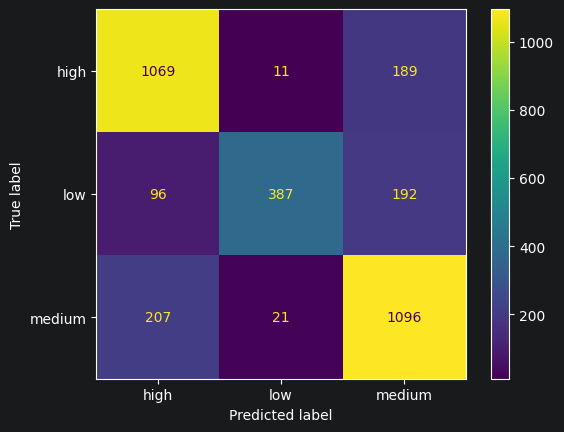

In [5]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    display_labels=priority_encoder.classes_
)

plt.show()

## Feature Importance

Random Forest provides feature importance scores that indicate which features contributed the most to the prediction.

The most influential features are visualized below.**

In [9]:
import numpy as np

feature_importance = pd.DataFrame({
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Importance
5013,0.015110
5005,0.008773
1006,0.004949
5008,0.004431
4374,0.004214
362,0.003979
5009,0.003668
4137,0.003499
5007,0.003446
2350,0.003302


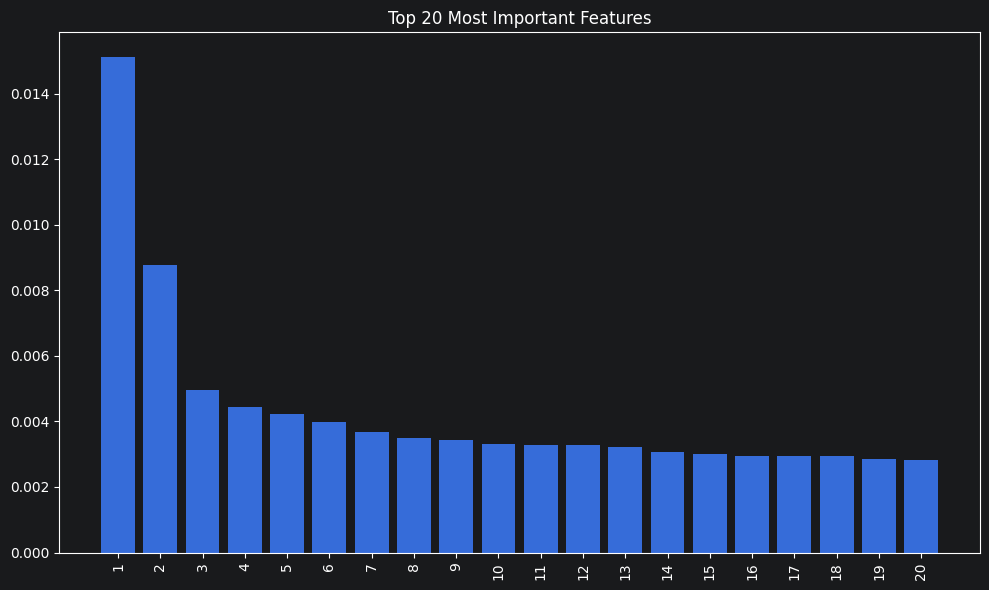

In [7]:
plt.figure(figsize=(10,6))

plt.bar(
    range(20),
    feature_importance["Importance"].head(20)
)

plt.xticks(
    range(20),
    range(1,21),
    rotation=90
)

plt.title("Top 20 Most Important Features")

plt.tight_layout()

plt.show()

## Cross Validation

Evaluate the stability and generalization performance of the selected production baseline model using 5-fold cross-validation.

In [10]:
scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation scores:")
print(scores)

print(f"\nMean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Cross-validation scores:
[0.75019128 0.74292272 0.75631217 0.7379495  0.74598317]

Mean Accuracy: 0.7467
Standard Deviation: 0.0063
